# Air Pollution and Health Outcomes
## Course Project - CS A1160 Beginner's Python for Engineers
### Team members and Roles (TODO!: Add roles):
- Lishchuk Oleksii
- Purnama Teodorus
- Yisunsri Napat

## Overview
This project analyzes the relationship between **air pollution levels** and **health outcomes**.

### Goal
Investigate the association of pollution levels with:
- Life expectancy, and
- Cardiovascular disease deaths

### Data Sources (TODO: CITE!!)
- Main Dataset: </br>
Air quality measurements of PM2.5, PM10, and NO2 (World Health Organization, 2024).
- Additional Dataset:</br>
Life expectancy and cardiovascular disease deaths (CITE!!!)

## Project Structure
This notebook follows the structure:
1. Libraries
2. Helper functions
3. Data reading
4. Data cleaning
5. Data merging
6. Statistics calculation
7. Plotting
8. Results interpretation

## Libraries
This project uses the following libraries to process the datasets.

In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

MAIN_FILE="main.xlsx"
ADDITIONAL_FILE="additional.csv"
SHEET_NAME="Update 2024 (V6.1)"

## Helper Functions


In [11]:
def clean_main_city_name(city_name): #Cleans inconsistent naming
    if pd.isna(city_name):
        return np.nan
    city_name=str(city_name)
    city_name=city_name.split("/")[0]
    city_name=re.sub(r"\s+[A-Z]{2}$","",city_name)
    return city_name.strip()

def annotate_all_points(df,x_col,y_col,label_col): # to annotate cities on first plots
    for i,row in df.iterrows():
        plt.annotate(row[label_col],(row[x_col],row[y_col]),fontsize=8)

def station_group(station_type): # for clarity of these freaking regions i officially hate that column and plot with it i hate it
    if pd.isna(station_type):
        return np.nan
    station_type=str(station_type).lower()
    if "suburban" in station_type:
        return "Suburban"
    if "urban" in station_type:
        return "Urban"
    if "rural" in station_type:
        return "Rural"
    return np.nan

def add_trendline(x,y):
    x=pd.Series(x).astype(float)
    y=pd.Series(y).astype(float)
    valid=pd.concat([x,y],axis=1).dropna()
    slope,intercept,i,j,k_=stats.linregress(valid.iloc[:,0],valid.iloc[:,1])
    x_line=np.linspace(valid.iloc[:,0].min(),valid.iloc[:,0].max(),200)
    y_line=slope*x_line+intercept
    plt.plot(x_line,y_line,color="red",label="Trendline")

def pearson_r(x,y):
    x=pd.Series(x).astype(float)
    y=pd.Series(y).astype(float)
    valid=pd.concat([x,y],axis=1).dropna()
    return stats.pearsonr(valid.iloc[:,0],valid.iloc[:,1])[0]

def scipy_skew(series):
    series=pd.Series(series).dropna()
    return stats.skew(series,bias=False)

def zscore_series(series):
    series=pd.Series(series).astype(float)
    return pd.Series(stats.zscore(series,nan_policy="omit"),index=series.index)

def summarize_with_ci(df,group_col,value_col,order):
    summary=df.groupby(group_col)[value_col].agg(["mean","std","count"]).reset_index()
    summary=summary[summary[group_col].isin(order)].copy()
    summary[group_col]=pd.Categorical(summary[group_col],categories=order,ordered=True)
    summary=summary.sort_values(group_col)
    summary["sem"]=summary["std"]/np.sqrt(summary["count"])
    summary["ci95"]=summary.apply(lambda row:stats.t.ppf(0.975,row["count"]-1)*row["sem"],axis=1)
    return summary

## Data Reading

In [12]:
main_raw=pd.read_excel(MAIN_FILE,sheet_name=SHEET_NAME)
additional_raw=pd.read_csv(ADDITIONAL_FILE)

## Data Cleaning
### Main Dataset
The main dataset includes data from various years and countries. This code filters the data to only includes data from the United States in the year 2020, so that the data is relevant to the additional dataset. The code also changes the name of the city to be consistent with the additional dataset.

In [13]:
main_us_2020 = main_raw[(main_raw["country_name"]=="United States of America")&(main_raw["year"]==2020)].copy()

main_us_2020["city_clean"] = main_us_2020["city"].apply(clean_main_city_name)

city_air = main_us_2020.groupby("city_clean")[["pm25_concentration","pm10_concentration","no2_concentration","population","latitude","longitude"]].mean().reset_index()

city_air = city_air.rename(columns={"pm25_concentration":"pm25_mean","pm10_concentration":"pm10_mean","no2_concentration":"no2_mean"})

station_info = main_us_2020.groupby("city_clean")["type_of_stations"].first().reset_index()

city_air=city_air.merge(station_info,on="city_clean",how="left")

city_air["station_group"]=city_air["type_of_stations"].apply(station_group)

### Additional Dataset
The additional dataset is cleaned by only taking the "Total" row for each city. This code also makes sure that only non-duplicate cities are used. Finally, it formats the dataset so that it is ready to be merged.

In [14]:
health_total=additional_raw[(additional_raw["geo_level"]=="city")&(additional_raw["group_name"]=="Total")].copy()

health_total=health_total[["geo_name","metric_name","est"]]
health_total=health_total.drop_duplicates(subset=["geo_name","metric_name"])

health_city=health_total.pivot(index="geo_name",columns="metric_name",values="est").reset_index()
health_city.columns.name = None

health_city=health_city.rename(columns={"geo_name":"city_clean","Cardiovascular Disease Deaths":"cvd_deaths","Life Expectancy - City-Level":"life_expectancy"})

## Data merging
The cleaned main and additional datasets are merged into "analysis_df".

In [15]:
merged=city_air.merge(health_city,on="city_clean",how="inner")
analysis_df=merged.copy()

## Statistical Calculations
This part of the code calculates and presents some basic statistical properties of the dataset.

### Shape
The shape of the datasets shows the filtering process of the datasets.

In [16]:
print("MAIN RAW DATASET SHAPE:")
print(main_raw.shape)
print("\nMAIN US 2020 DATASET SHAPE:")
print(main_us_2020.shape)
print("\nCITY AIR DATASET SHAPE:")
print(city_air.shape)
print("\nHEALTH TOTAL DATASET SHAPE:")
print(health_total.shape)
print("\nHEALTH CITY DATASET SHAPE:")
print(health_city.shape)
print("\nMERGED DATASET SHAPE:")
print(merged.shape)
print("\nFINAL ANALYSIS DATASET SHAPE:")
print(analysis_df.shape)

#Store the name of relevant columns together for convenience
city_air_cols=["pm25_mean","pm10_mean","no2_mean","population","latitude","longitude"]
health_cols=["life_expectancy","cvd_deaths"]
merged_cols=["pm25_mean","pm10_mean","no2_mean","population","latitude","longitude","life_expectancy","cvd_deaths"]

MAIN RAW DATASET SHAPE:
(40098, 20)

MAIN US 2020 DATASET SHAPE:
(324, 21)

CITY AIR DATASET SHAPE:
(321, 9)

HEALTH TOTAL DATASET SHAPE:
(2280, 3)

HEALTH CITY DATASET SHAPE:
(1140, 3)

MERGED DATASET SHAPE:
(124, 11)

FINAL ANALYSIS DATASET SHAPE:
(124, 11)


In [17]:
city_air_stats=pd.DataFrame({"mean":city_air[city_air_cols].mean(),"std":city_air[city_air_cols].std(),"min":city_air[city_air_cols].min(),"max":city_air[city_air_cols].max(),"skew":city_air[city_air_cols].apply(scipy_skew)})
print("\nSummary statistics for city_air:")
print(city_air_stats)

health_city_stats=pd.DataFrame({"mean":health_city[health_cols].mean(),"std":health_city[health_cols].std(),"min":health_city[health_cols].min(),"max":health_city[health_cols].max(),"skew":health_city[health_cols].apply(scipy_skew)})
print("\nSummary statistics for health_city:")
print(health_city_stats)

merged_stats=pd.DataFrame({"mean":merged[merged_cols].mean(),"std":merged[merged_cols].std(),"min":merged[merged_cols].min(),"max":merged[merged_cols].max(),"skew":merged[merged_cols].apply(scipy_skew)})
print("\nSummary statistics for merged:")
print(merged_stats)

analysis_stats=pd.DataFrame({"mean":analysis_df[merged_cols].mean(),"std":analysis_df[merged_cols].std(),"min":analysis_df[merged_cols].min(),"max":analysis_df[merged_cols].max(),"skew":analysis_df[merged_cols].apply(scipy_skew)})

print("\nSummary statistics for analysis_df:")
print(analysis_stats)
print("\nCorrelation matrix for city_air:")
print(city_air[city_air_cols].corr())
print("\nCorrelation matrix for health_city:")
print(health_city[health_cols].corr())
print("\nCorrelation matrix for merged:")
print(merged[merged_cols].corr())
correlation_matrix=analysis_df[merged_cols].corr()
print("\nCorrelation matrix for analysis_df:")
print(correlation_matrix)


Summary statistics for city_air:
                     mean           std         min           max      skew
pm25_mean        7.932374  2.622628e+00    2.360000  2.000000e+01  2.085423
pm10_mean       19.770000  8.933436e+00    5.700000  5.510000e+01  1.578759
no2_mean        11.393289  5.854750e+00    1.100000  2.910000e+01  0.689452
population  816042.582397  1.813739e+06   20.000000  1.880355e+07  5.676269
latitude        38.176970  5.550913e+00   19.420849  6.484569e+01  0.124824
longitude      -94.429732  1.712140e+01 -159.366240 -6.978672e+01 -1.083419

Summary statistics for health_city:
                       mean        std   min    max      skew
life_expectancy   77.873209   4.252795  65.0   95.3  0.032756
cvd_deaths       211.713217  71.956759  46.4  597.5  1.287296

Summary statistics for merged:
                          mean            std          min           max  \
pm25_mean             7.842381       2.729678     3.700000  2.000000e+01   
pm10_mean            22.203

## Plotting

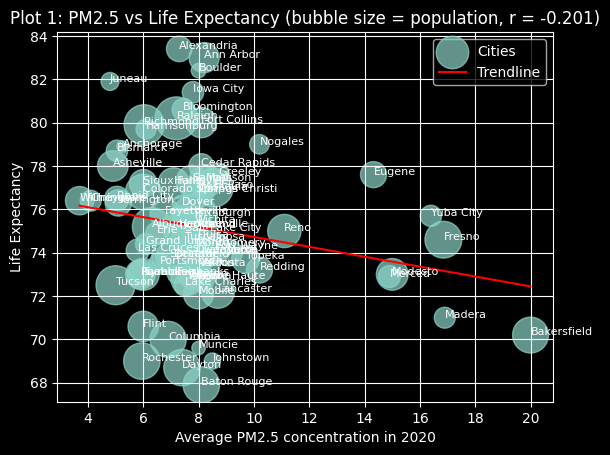

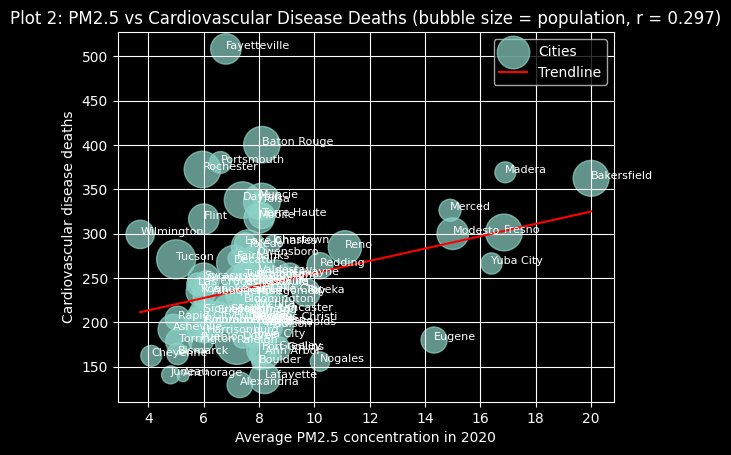

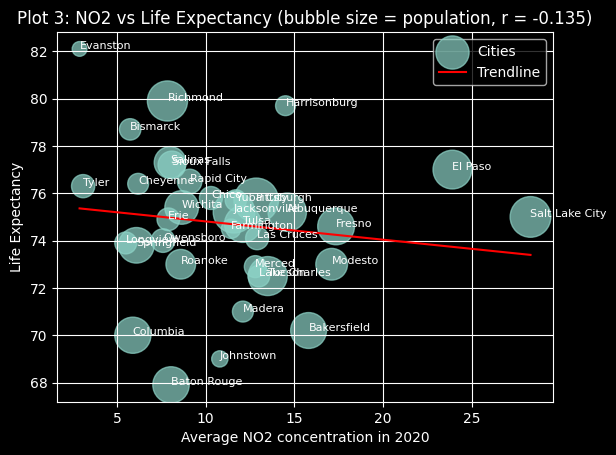

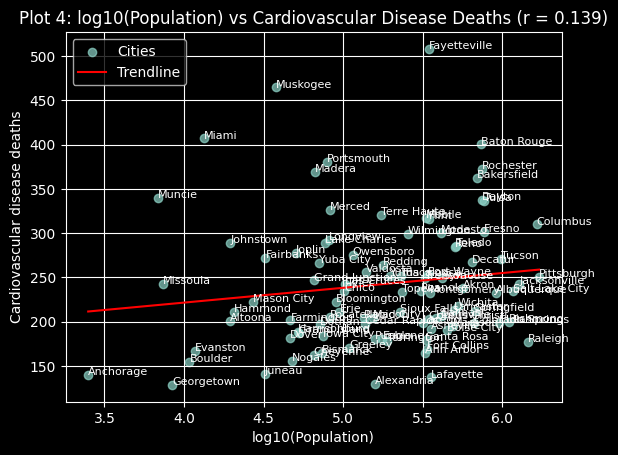

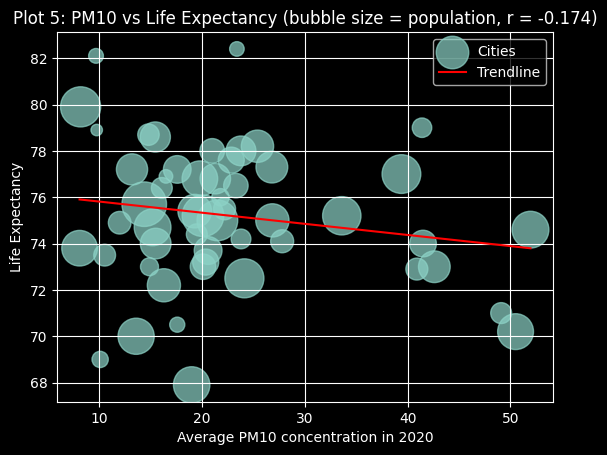

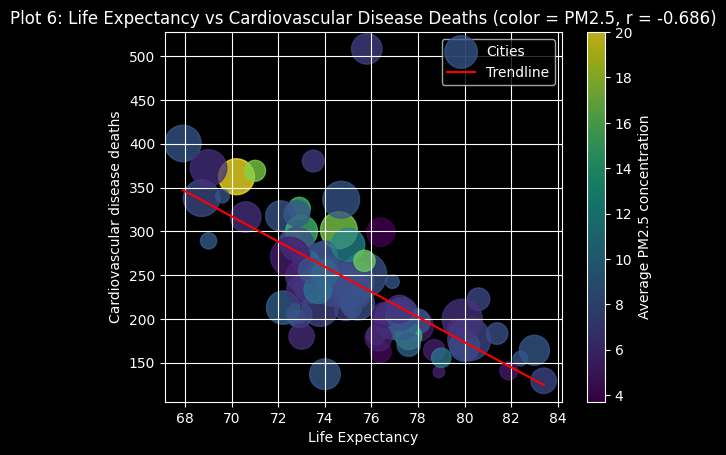

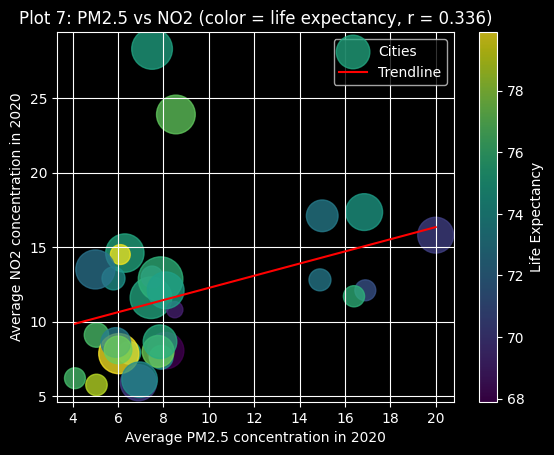

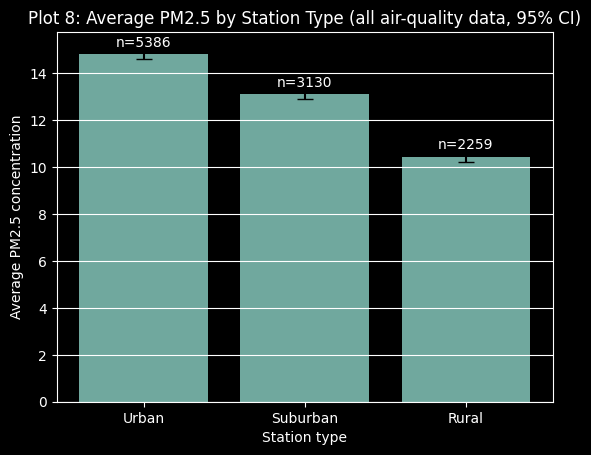

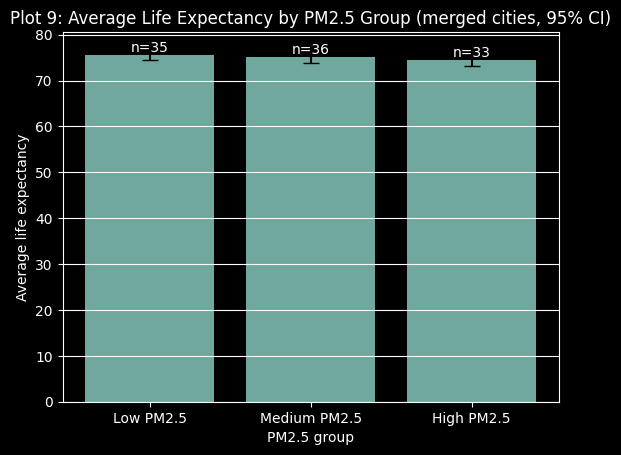

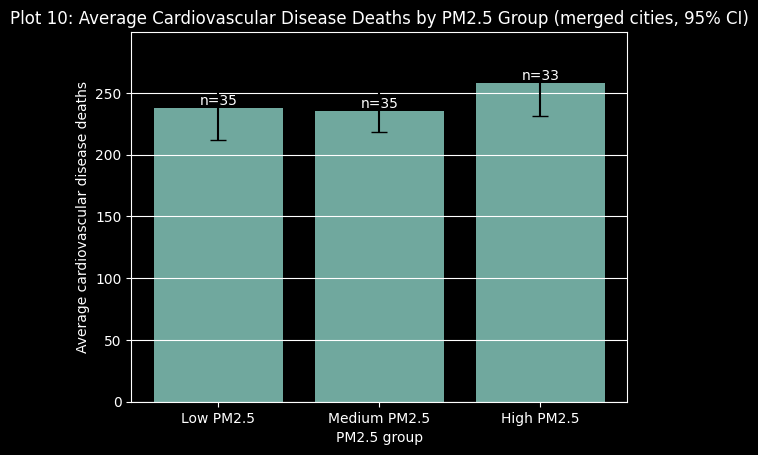

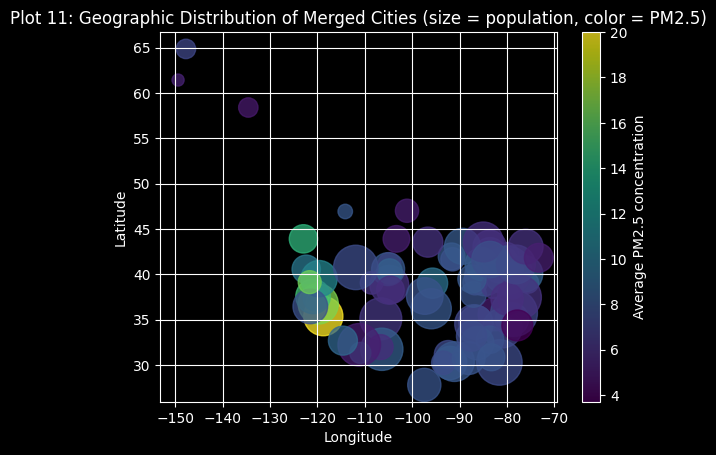

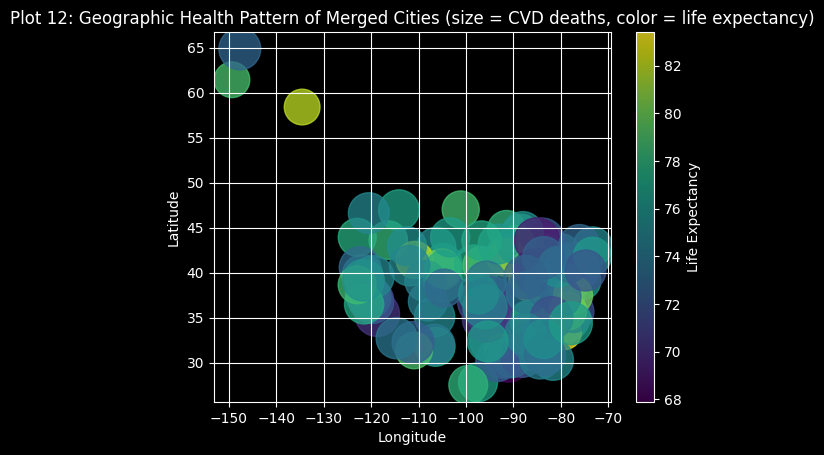

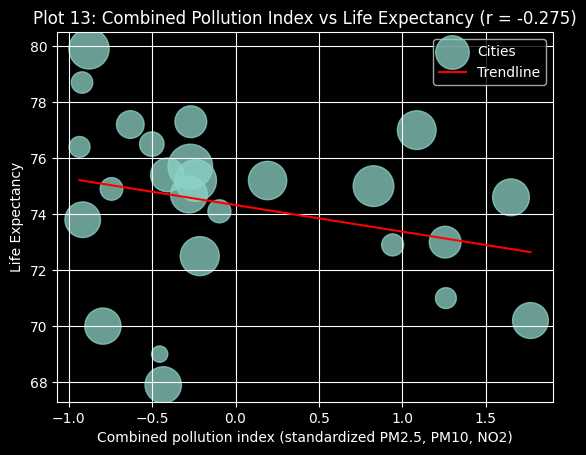

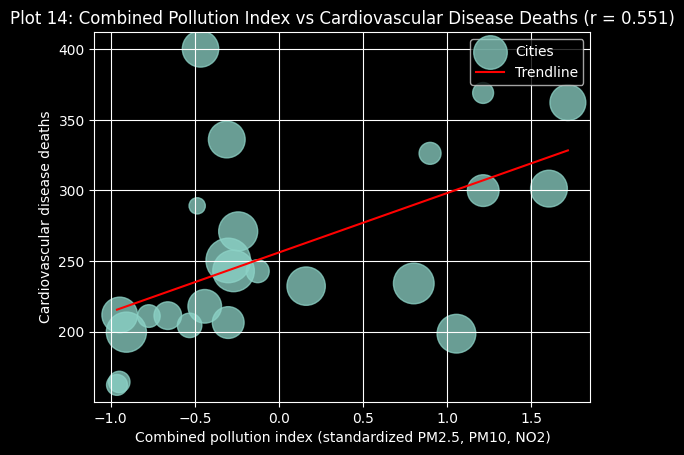

In [18]:
# Plot 1 cpm vs life
plot_df_1=analysis_df[["pm25_mean","life_expectancy","population","city_clean"]].dropna().copy()
x1=plot_df_1["pm25_mean"]
y1=plot_df_1["life_expectancy"]
r1=pearson_r(x1,y1)
sizes1=np.sqrt(plot_df_1["population"])/np.sqrt(plot_df_1["population"]).max()*1000+30
plt.figure()
plt.scatter(x1,y1,s=sizes1,alpha=0.7,label="Cities")
add_trendline(x1,y1)
annotate_all_points(plot_df_1,"pm25_mean","life_expectancy","city_clean")
plt.title(f"Plot 1: PM2.5 vs Life Expectancy (bubble size = population, r = {r1:.3f})")
plt.xlabel("Average PM2.5 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot1_pm25_vs_life_expectancy.png")
plt.show()

# Plot 2 pm vs death and cities are labeleed
plot_df_2=analysis_df[["pm25_mean","cvd_deaths","population","city_clean"]].dropna().copy()
x2=plot_df_2["pm25_mean"]
y2=plot_df_2["cvd_deaths"]
r2=pearson_r(x2,y2)
sizes2=np.sqrt(plot_df_2["population"])/np.sqrt(plot_df_2["population"]).max()*1000+30
plt.figure()
plt.scatter(x2,y2,s=sizes2,alpha=0.7,label="Cities")
add_trendline(x2,y2)
annotate_all_points(plot_df_2,"pm25_mean","cvd_deaths","city_clean")
plt.title(f"Plot 2: PM2.5 vs Cardiovascular Disease Deaths (bubble size = population, r = {r2:.3f})")
plt.xlabel("Average PM2.5 concentration in 2020")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot2_pm25_vs_cvd_deaths.png")
plt.show()

# Plot 3 no2 vs life
plot_df_3=analysis_df[["no2_mean","life_expectancy","population","city_clean"]].dropna().copy()
x3=plot_df_3["no2_mean"]
y3=plot_df_3["life_expectancy"]
r3=pearson_r(x3,y3)
sizes3=np.sqrt(plot_df_3["population"])/np.sqrt(plot_df_3["population"]).max()*1000+30
plt.figure()
plt.scatter(x3,y3,s=sizes3,alpha=0.7,label="Cities")
add_trendline(x3,y3)
annotate_all_points(plot_df_3,"no2_mean","life_expectancy","city_clean")
plt.title(f"Plot 3: NO2 vs Life Expectancy (bubble size = population, r = {r3:.3f})")
plt.xlabel("Average NO2 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot3_no2_vs_life_expectancy.png")
plt.show()


# Plot 4 popul vs disease just to show there are not any dependancy here so we can justify that it is not dependant on population, bcecause otherwise in all our project we have that eveything is dependednt lets add this so we will have at least one opposite example
plot_df_4=analysis_df[["population","cvd_deaths","city_clean"]].dropna().copy()
plot_df_4["log_population"]=np.log10(plot_df_4["population"])
x4=plot_df_4["log_population"]
y4=plot_df_4["cvd_deaths"]
r4=pearson_r(x4,y4)
plt.figure()
plt.scatter(x4,y4,alpha=0.7,label="Cities")
add_trendline(x4,y4)
annotate_all_points(plot_df_4,"log_population","cvd_deaths","city_clean")
plt.title(f"Plot 4: log10(Population) vs Cardiovascular Disease Deaths (r = {r4:.3f})")
plt.xlabel("log10(Population)")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot4_log_population_vs_cvd_deaths.png")
plt.show()

# Plot 5 pm vs life
plot_df_5=analysis_df[["pm10_mean","life_expectancy","population"]].dropna().copy()
x5=plot_df_5["pm10_mean"]
y5=plot_df_5["life_expectancy"]
r5=pearson_r(x5,y5)
sizes5=np.sqrt(plot_df_5["population"])/np.sqrt(plot_df_5["population"]).max()*1000+30
plt.figure()
plt.scatter(x5,y5,s=sizes5,alpha=0.7,label="Cities")
add_trendline(x5,y5)
plt.title(f"Plot 5: PM10 vs Life Expectancy (bubble size = population, r = {r5:.3f})")
plt.xlabel("Average PM10 concentration in 2020")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot5_pm10_vs_life_expectancy.png")
plt.show()


# Plt 6 life vs death i guess main plot
# this scatter plot with this thing on the left I found it in the desctiption of a library i hope i used it correctly because i am doing it for the first time so i am not that sure in the correctness of the graphs 6 7 11 12
plot_df_6=analysis_df[["life_expectancy","cvd_deaths","pm25_mean","population"]].dropna().copy()
x6=plot_df_6["life_expectancy"]
y6=plot_df_6["cvd_deaths"]
r6=pearson_r(x6,y6)
sizes6=np.sqrt(plot_df_6["population"])/np.sqrt(plot_df_6["population"]).max()*1000+30
plt.figure()
scatter6=plt.scatter(x6,y6,s=sizes6,c=plot_df_6["pm25_mean"],alpha=0.75,label="Cities")
plt.colorbar(scatter6,label="Average PM2.5 concentration")
add_trendline(x6,y6)
plt.title(f"Plot 6: Life Expectancy vs Cardiovascular Disease Deaths (color = PM2.5, r = {r6:.3f})")
plt.xlabel("Life Expectancy")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot6_life_expectancy_vs_cvd_deaths_pm25.png")
plt.show()

# Plot 7 pm vs no2
plot_df_7=analysis_df[["pm25_mean","no2_mean","life_expectancy","population"]].dropna().copy()
x7=plot_df_7["pm25_mean"]
y7=plot_df_7["no2_mean"]
r7=pearson_r(x7,y7)
sizes7=np.sqrt(plot_df_7["population"])/np.sqrt(plot_df_7["population"]).max()*1000+30
plt.figure()
scatter7=plt.scatter(x7,y7,s=sizes7,c=plot_df_7["life_expectancy"],alpha=0.75,label="Cities")
plt.colorbar(scatter7,label="Life Expectancy")
add_trendline(x7,y7)
plt.title(f"Plot 7: PM2.5 vs NO2 (color = life expectancy, r = {r7:.3f})")
plt.xlabel("Average PM2.5 concentration in 2020")
plt.ylabel("Average NO2 concentration in 2020")
plt.legend()
plt.grid()
plt.savefig("plot7_pm25_vs_no2_life_expectancy_color.png")
plt.show()

# Plot 8  i wanted to use the rural urban and suburban column
plot_df_8=main_raw.copy()
plot_df_8["station_group"]=plot_df_8["type_of_stations"].apply(station_group)
plot_df_8=plot_df_8[plot_df_8["station_group"].isin(["Urban","Suburban","Rural"])].copy()
plot_df_8=plot_df_8[["station_group","pm25_concentration"]].dropna()
station_pm25=summarize_with_ci(plot_df_8,group_col="station_group",value_col="pm25_concentration",order=["Urban","Suburban","Rural"])
plt.figure()
bars8=plt.bar(station_pm25["station_group"],station_pm25["mean"],yerr=station_pm25["ci95"],capsize=6,alpha=0.8)
for bar,n in zip(bars8,station_pm25["count"]):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,f"n={int(n)}",ha="center",va="bottom")
plt.title("Plot 8: Average PM2.5 by Station Type (all air-quality data, 95% CI)")
plt.xlabel("Station type")
plt.ylabel("Average PM2.5 concentration")
plt.grid(axis="y")
plt.savefig("plot8_pm25_by_station_type.png")
plt.show()


# Plot 9  main plot with 10 life vs contamination
plot_df_9=analysis_df[["pm25_mean","life_expectancy"]].dropna().copy()
plot_df_9["pm25_group"]=pd.qcut(plot_df_9["pm25_mean"],q=3,labels=["Low PM2.5","Medium PM2.5","High PM2.5"])
life_by_pm25=summarize_with_ci(plot_df_9,group_col="pm25_group",value_col="life_expectancy",order=["Low PM2.5","Medium PM2.5","High PM2.5"])
plt.figure()
bars9=plt.bar(life_by_pm25["pm25_group"],life_by_pm25["mean"],yerr=life_by_pm25["ci95"],capsize=6,alpha=0.8)
for bar,n in zip(bars9,life_by_pm25["count"]):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.03,f"n={int(n)}",ha="center",va="bottom")
plt.title("Plot 9: Average Life Expectancy by PM2.5 Group (merged cities, 95% CI)")
plt.xlabel("PM2.5 group")
plt.ylabel("Average life expectancy")
plt.grid(axis="y")
plt.savefig("plot9_life_expectancy_by_pm25_group.png")
plt.show()

# Plot 10 maybe main plot pm vs death
plot_df_10=analysis_df[["pm25_mean","cvd_deaths"]].dropna().copy()
plot_df_10["pm25_group"]=pd.qcut(plot_df_10["pm25_mean"],q=3,labels=["Low PM2.5","Medium PM2.5","High PM2.5"])
cvd_by_pm25=summarize_with_ci(plot_df_10,group_col="pm25_group",value_col="cvd_deaths",order=["Low PM2.5","Medium PM2.5","High PM2.5"])
plt.figure()
bars10=plt.bar(cvd_by_pm25["pm25_group"],cvd_by_pm25["mean"],yerr=cvd_by_pm25["ci95"],capsize=6,alpha=0.8)
for bar,n in zip(bars10,cvd_by_pm25["count"]):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.2,f"n={int(n)}",ha="center",va="bottom")
plt.title("Plot 10: Average Cardiovascular Disease Deaths by PM2.5 Group (merged cities, 95% CI)")
plt.xlabel("PM2.5 group")
plt.ylabel("Average cardiovascular disease deaths")
plt.grid(axis="y")
plt.savefig("plot10_cvd_by_pm25_group.png")
plt.show()
# Plot 11 geography of pm2.5 contamination, i propose adding a map of world and i guess we can than compare with plot 12
plot_df_11=analysis_df[["longitude","latitude","population","pm25_mean"]].dropna().copy()
sizes11=np.sqrt(plot_df_11["population"])/np.sqrt(plot_df_11["population"]).max()*1200+30
plt.figure()
scatter11=plt.scatter(plot_df_11["longitude"],plot_df_11["latitude"],s=sizes11,c=plot_df_11["pm25_mean"],alpha=0.75)
plt.colorbar(scatter11,label="Average PM2.5 concentration")
plt.title("Plot 11: Geographic Distribution of Merged Cities (size = population, color = PM2.5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.savefig("plot11_geo_population_pm25.png")
plt.show()

# Plot 12 just geography maybe then on the slide we can show the map with latitude and longtitude or something
plot_df_12=analysis_df[["longitude","latitude","cvd_deaths","life_expectancy"]].dropna().copy()
sizes12=np.sqrt(plot_df_12["cvd_deaths"])/np.sqrt(plot_df_12["cvd_deaths"]).max()*1200+30
plt.figure()
scatter12=plt.scatter(plot_df_12["longitude"],plot_df_12["latitude"],s=sizes12,c=plot_df_12["life_expectancy"],alpha=0.75)
plt.colorbar(scatter12,label="Life Expectancy")
plt.title("Plot 12: Geographic Health Pattern of Merged Cities (size = CVD deaths, color = life expectancy)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.savefig("plot12_geo_cvd_life_expectancy.png")
plt.show()

# Plot 13 combined pollution index vs life expectancy  so we can compare then with 14th
plot_df_13=analysis_df[["pm25_mean","pm10_mean","no2_mean","life_expectancy","population"]].dropna().copy()
plot_df_13["pm25_z"]=zscore_series(plot_df_13["pm25_mean"])
plot_df_13["pm10_z"]=zscore_series(plot_df_13["pm10_mean"])
plot_df_13["no2_z"]=zscore_series(plot_df_13["no2_mean"])
plot_df_13["pollution_index"]=(plot_df_13["pm25_z"]+plot_df_13["pm10_z"]+plot_df_13["no2_z"])/3
x13=plot_df_13["pollution_index"]
y13=plot_df_13["life_expectancy"]
r13=pearson_r(x13,y13)
sizes13=np.sqrt(plot_df_13["population"])/np.sqrt(plot_df_13["population"]).max()*1000+30
plt.figure()
plt.scatter(x13,y13,s=sizes13,alpha=0.75,label="Cities")
add_trendline(x13,y13)
plt.title(f"Plot 13: Combined Pollution Index vs Life Expectancy (r = {r13:.3f})")
plt.xlabel("Combined pollution index (standardized PM2.5, PM10, NO2)")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid()
plt.savefig("plot13_pollution_index_vs_life_expectancy.png")
plt.show()
# Plot 14 combined pollution index vs cardiovascular disease death
plot_df_14=analysis_df[["pm25_mean","pm10_mean","no2_mean","cvd_deaths","population"]].dropna().copy()
plot_df_14["pm25_z"]=zscore_series(plot_df_14["pm25_mean"])
plot_df_14["pm10_z"]=zscore_series(plot_df_14["pm10_mean"])
plot_df_14["no2_z"]=zscore_series(plot_df_14["no2_mean"])
plot_df_14["pollution_index"]=(plot_df_14["pm25_z"]+plot_df_14["pm10_z"]+plot_df_14["no2_z"])/3
x14=plot_df_14["pollution_index"]
y14=plot_df_14["cvd_deaths"]
r14=pearson_r(x14,y14)
sizes14=np.sqrt(plot_df_14["population"])/np.sqrt(plot_df_14["population"]).max()*1000+30
plt.figure()
plt.scatter(x14,y14,s=sizes14,alpha=0.75,label="Cities")
add_trendline(x14,y14)
plt.title(f"Plot 14: Combined Pollution Index vs Cardiovascular Disease Deaths (r = {r14:.3f})")
plt.xlabel("Combined pollution index (standardized PM2.5, PM10, NO2)")
plt.ylabel("Cardiovascular disease deaths")
plt.legend()
plt.grid()
plt.savefig("plot14_pollution_index_vs_cvd_deaths.png")
plt.show()

## Result Interpretation

In [19]:
print("\nMain correlations (merged dataset focus):")
print(f"PM2.5 vs Life Expectancy: {r1:.3f}")
print(f"PM2.5 vs CVD Deaths: {r2:.3f}")
print(f"NO2 vs Life Expectancy: {r3:.3f}")
print(f"log10(Population) vs CVD Deaths: {r4:.3f}")
print(f"PM10 vs Life Expectancy: {r5:.3f}")
print(f"Life Expectancy vs CVD Deaths: {r6:.3f}")
print(f"PM2.5 vs NO2: {r7:.3f}")
print(f"Combined Pollution Index vs Life Expectancy: {r13:.3f}")
print(f"Combined Pollution Index vs CVD Deaths: {r14:.3f}")
print(f"Matched cities in merged dataset: {analysis_df['city_clean'].nunique()}")
print("\nStation type counts in merged US dataset from original 2020 field:")
print(analysis_df["station_group"].value_counts(dropna=False))
print("\nStation type counts used in plot 8:")
print(station_pm25[["station_group","count"]])


Main correlations (merged dataset focus):
PM2.5 vs Life Expectancy: -0.201
PM2.5 vs CVD Deaths: 0.297
NO2 vs Life Expectancy: -0.135
log10(Population) vs CVD Deaths: 0.139
PM10 vs Life Expectancy: -0.174
Life Expectancy vs CVD Deaths: -0.686
PM2.5 vs NO2: 0.336
Combined Pollution Index vs Life Expectancy: -0.275
Combined Pollution Index vs CVD Deaths: 0.551
Matched cities in merged dataset: 124

Station type counts in merged US dataset from original 2020 field:
station_group
NaN    124
Name: count, dtype: int64

Station type counts used in plot 8:
  station_group  count
2         Urban   5386
1      Suburban   3130
0         Rural   2259


## References
- World Health Organization (2024) _WHO Ambient Air Quality Database (Update Jan 2024)_. Available at: https://www.who.int/publications/m/item/who-ambient-air-quality-database-(update-jan-2024). [Accessed 27 March 2026]
-